# **Mental Health in Tech Survey - EDA**

##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

This project analyzes the 2014 Open Sourcing Mental Illness (OSMI) survey, which captures attitudes toward mental health and the frequency of mental health disorders within the tech workplace. The dataset contains 1,259 responses across 27 variables covering demographics (Age, Gender, Country, state), employment characteristics (company size, remote work, self-employment, tech company status), and a wide range of workplace attitudes and policies around mental health (benefits, care options, wellness programs, anonymity protections, ease of taking leave, willingness to discuss mental health with coworkers/supervisors, and perceived consequences of disclosure).

The primary goal of this EDA is to understand how mental health is perceived and supported in tech workplaces, and to identify which factors are most strongly associated with whether an employee has sought treatment for a mental health condition. The analysis follows a structured approach: first inspecting and cleaning the raw survey data (handling messy free-text fields like Gender, unrealistic Age values, and missing responses), then exploring individual variables (univariate analysis), relationships between pairs of variables such as treatment status against family history, benefits, or work interference (bivariate analysis), and finally combined multi-factor views such as treatment patterns across Gender and family history together (multivariate analysis).

Key questions explored include: How does company size, remote work, or benefits availability relate to whether someone sought treatment? Does having a family history of mental illness increase the likelihood of seeking treatment? How comfortable are employees discussing mental health with coworkers versus supervisors, and does that comfort level relate to whether they've observed negative consequences at work? Which countries are most represented in the survey, and do treatment rates vary geographically?

The insights from this analysis are intended to help HR teams and tech employers understand gaps in mental health support - for example, whether wellness programs and benefits are actually reaching employees who need them, and whether policies around anonymity and leave are perceived as adequate. The notebook concludes with concrete, data-backed recommendations for improving mental health support in tech workplaces, followed by a summary of the most important findings.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**

**Attitudes toward mental health in the tech industry remain inconsistent, and many employees are unsure whether their workplace genuinely supports mental health disclosure and treatment. This analysis explores the 2014 OSMI survey data to uncover patterns in mental health treatment-seeking behavior and workplace support structures across the tech industry.**

#### **Define Your Business Objective?**

To identify the key demographic and workplace factors (family history, company size, benefits, remote work, perceived consequences, etc.) that are associated with an employee seeking treatment for a mental health condition, and to surface actionable recommendations that tech employers can use to improve mental health support and reduce stigma in the workplace.

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
sns.set_palette('muted')


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('survey.csv')


### Dataset First View

In [3]:
# Dataset First Look
df.head()


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Rows: 1259
Columns: 27


### Dataset Information

In [5]:
# Dataset Info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum().sort_values(ascending=False)


comments                     1095
state                         515
work_interfere                264
self_employed                  18
Gender                          0
Timestamp                       0
Age                             0
family_history                  0
treatment                       0
no_employees                    0
Country                         0
remote_work                     0
tech_company                    0
care_options                    0
benefits                        0
seek_help                       0
anonymity                       0
leave                           0
wellness_program                0
mental_health_consequence       0
phys_health_consequence         0
supervisor                      0
coworkers                       0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
dtype: int64

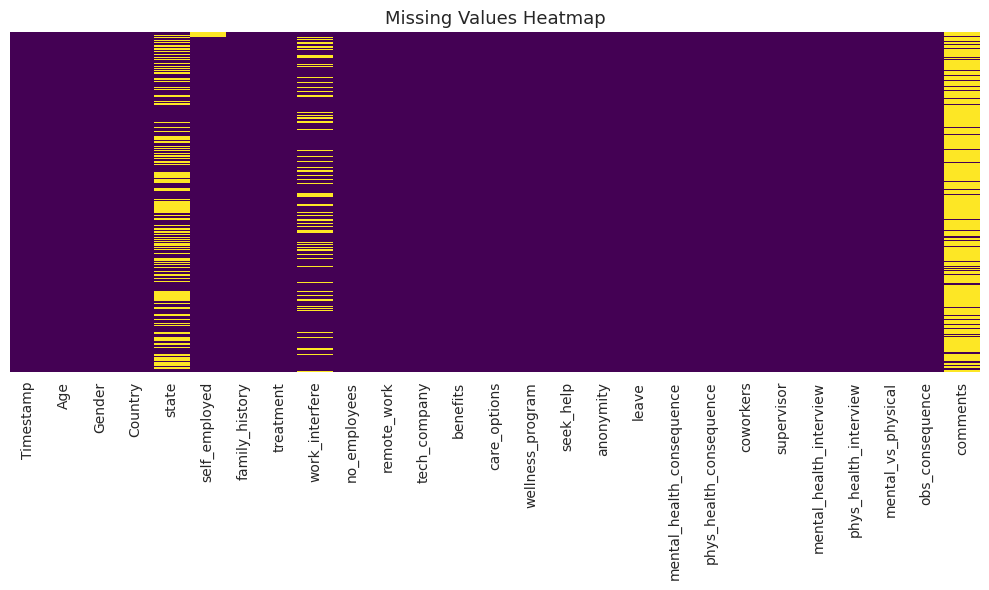

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()


### What did you know about your dataset?

The dataset has 1,259 rows and 27 columns, with no duplicate rows. Most columns are complete, but `comments` is missing for the vast majority of respondents (1,095 of 1,259), `state` is missing for anyone outside the US (515 missing), `work_interfere` is missing for respondents who don't have a mental health condition (264 missing), and `self_employed` has a small number of missing values (18). The `Age` column contains clearly invalid entries (negative values and absurdly large values like 100 billion), and `Gender` is a free-text field with dozens of inconsistent spellings and variants (e.g. 'Male', 'male', 'M', 'Cis Male', 'Malr', 'something kinda male?') that will need to be standardized before analysis.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()


['Timestamp',
 'Age',
 'Gender',
 'Country',
 'state',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence',
 'comments']

In [10]:
# Dataset Describe
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981968,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

- **Timestamp**: Date/time the survey response was submitted
- **Age**: Respondent's age (contains invalid outliers to be cleaned)
- **Gender**: Free-text gender field (needs standardization)
- **Country**: Respondent's country
- **state**: US state/territory (only applicable to US respondents)
- **self_employed**: Whether the respondent is self-employed
- **family_history**: Family history of mental illness
- **treatment**: Whether the respondent has sought treatment for a mental health condition (**target variable of interest**)
- **work_interfere**: Whether the mental health condition interferes with work
- **no_employees**: Company size bucket
- **remote_work**: Works remotely at least 50% of the time
- **tech_company**: Whether the employer is primarily a tech company
- **benefits**: Employer provides mental health benefits
- **care_options**: Awareness of employer's mental health care options
- **wellness_program**: Employer discussed mental health in a wellness program
- **seek_help**: Employer provides resources to learn about mental health/seeking help
- **anonymity**: Anonymity protected when using mental health resources
- **leave**: Ease of taking medical leave for a mental health condition
- **mental_health_consequence**: Perceived negative consequences of discussing mental health with employer
- **phys_health_consequence**: Perceived negative consequences of discussing physical health with employer
- **coworkers**: Willingness to discuss mental health with coworkers
- **supervisor**: Willingness to discuss mental health with supervisor(s)
- **mental_health_interview**: Would bring up mental health in a job interview
- **phys_health_interview**: Would bring up physical health in a job interview
- **mental_vs_physical**: Whether employer treats mental health as seriously as physical health
- **obs_consequence**: Observed negative consequences for coworkers with mental health conditions
- **comments**: Free-text additional comments

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Timestamp: 1246 unique values
Age: 53 unique values
Gender: 49 unique values
Country: 48 unique values
state: 45 unique values
self_employed: 2 unique values
family_history: 2 unique values
treatment: 2 unique values
work_interfere: 4 unique values
no_employees: 6 unique values
remote_work: 2 unique values
tech_company: 2 unique values
benefits: 3 unique values
care_options: 3 unique values
wellness_program: 3 unique values
seek_help: 3 unique values
anonymity: 3 unique values
leave: 5 unique values
mental_health_consequence: 3 unique values
phys_health_consequence: 3 unique values
coworkers: 3 unique values
supervisor: 3 unique values
mental_health_interview: 3 unique values
phys_health_interview: 3 unique values
mental_vs_physical: 3 unique values
obs_consequence: 2 unique values
comments: 160 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# --- Clean Age: keep only realistic working-age values, rest -> NaN, then impute with median ---
df.loc[(df['Age'] < 15) | (df['Age'] > 100), 'Age'] = np.nan
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'] = df['Age'].astype(int)

# --- Standardize Gender into Male / Female / Other ---
def clean_gender(g):
    g = str(g).strip().lower()
    male_vals = ['male', 'm', 'man', 'cis male', 'cis man', 'malr', 'mal', 'maile',
                 'make', 'male-ish', 'male (cis)', 'guy (-ish) ^_^', 'msle',
                 'mail', 'male leaning androgynous', 'ostensibly male, unsure what that really means']
    female_vals = ['female', 'f', 'woman', 'cis female', 'femake', 'female (cis)',
                    'female (trans)', 'cis-female/femme', 'trans woman', 'femail']
    if g in male_vals:
        return 'Male'
    elif g in female_vals:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

# --- Convert Timestamp to datetime ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# --- Handle missing values ---
df['self_employed'] = df['self_employed'].fillna('No')
df['work_interfere'] = df['work_interfere'].fillna('Not applicable')
df['state'] = df['state'].fillna('Not in US')
df = df.drop(columns=['comments'])  # too sparse to be useful for EDA

print("Missing values after cleaning:")
print(df.isnull().sum().sum())


Missing values after cleaning:
0


### What all manipulations have you done and insights you found?

`Age` was capped to a realistic 15-100 range (invalid entries like negative numbers and 100 billion were replaced with the median age). `Gender` was collapsed from 49 inconsistent free-text variants into three clean categories: Male, Female, and Other. `Timestamp` was converted to a proper datetime type. `self_employed` and `work_interfere` missing values were filled with sensible defaults ('No' and 'Not applicable' respectively), `state` missing values were labeled 'Not in US' since they correspond to non-US respondents, and the sparse `comments` column was dropped since it was missing for 87% of respondents and not useful for structured analysis. After cleaning, the dataset has zero missing values and is ready for visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Age Distribution

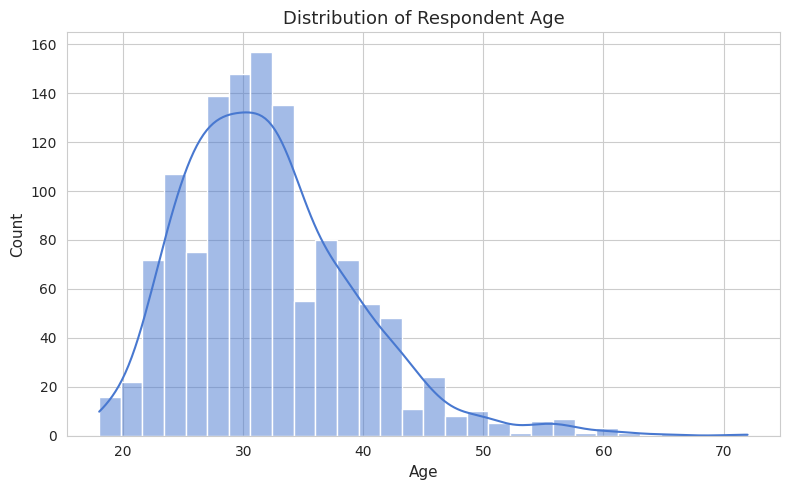

In [13]:
plt.figure()
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Respondent Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the standard way to show the shape and spread of a single continuous variable like Age.

##### 2. What is/are the insight(s) found from the chart?

The respondent age is fairly normally distributed, concentrated between roughly 25 and 40 years, with a peak around 28-32 - consistent with a workforce skewed toward early-to-mid career tech employees.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes - knowing the workforce is predominantly younger tech employees helps HR tailor mental health programs (e.g. early-career stress, burnout) to the age group actually represented. No negative growth signal here, it's descriptive context.

#### Chart - 2 - Gender Distribution

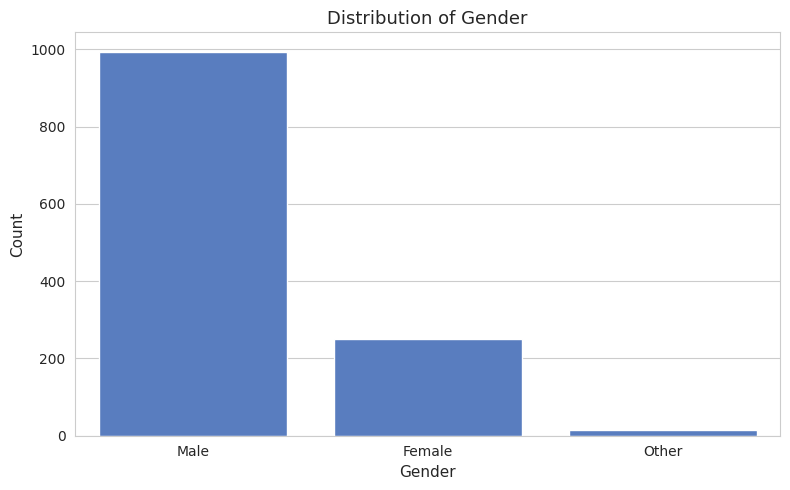

In [14]:
plt.figure()
sns.countplot(data=df, x='Gender', order=df['Gender'].value_counts().index)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A count plot is ideal for showing frequency across a categorical variable with few categories.

##### 2. What is/are the insight(s) found from the chart?

The survey respondents are overwhelmingly Male, with Female and Other categories being a much smaller share - reflecting the well-known gender imbalance in the tech industry.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is important context rather than a positive/negative signal by itself - it means findings about treatment-seeking by gender should be interpreted cautiously given the sample imbalance, and employers should ensure mental health programs aren't unintentionally designed around the majority group only.

#### Chart - 3 - Top 10 Countries by Respondent Count

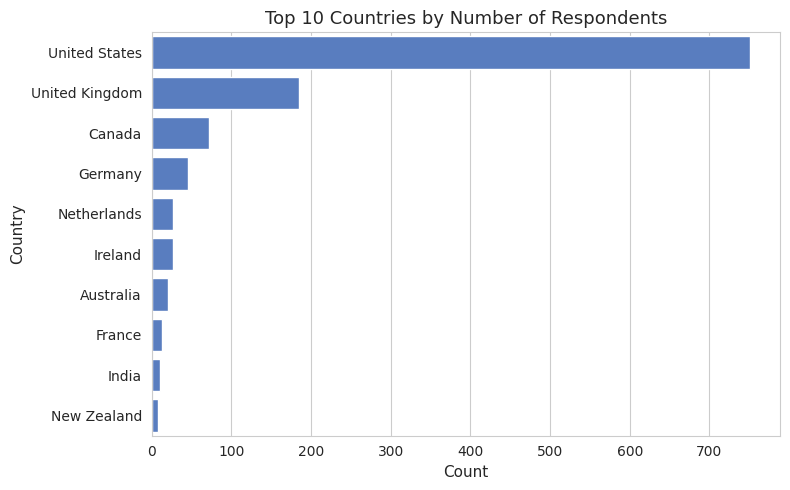

In [15]:
plt.figure()
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Number of Respondents')
plt.xlabel('Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart works well for ranking categories (countries) by frequency, especially with longer category labels.

##### 2. What is/are the insight(s) found from the chart?

The United States dominates the survey responses by a large margin, followed by the UK and Canada - the survey is heavily US-centric.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful for interpreting geographic findings correctly - any 'by country' insights are really driven mostly by US respondents. Employers outside the US should treat country-level conclusions carefully due to limited sample size elsewhere.

#### Chart - 4 - Treatment Distribution

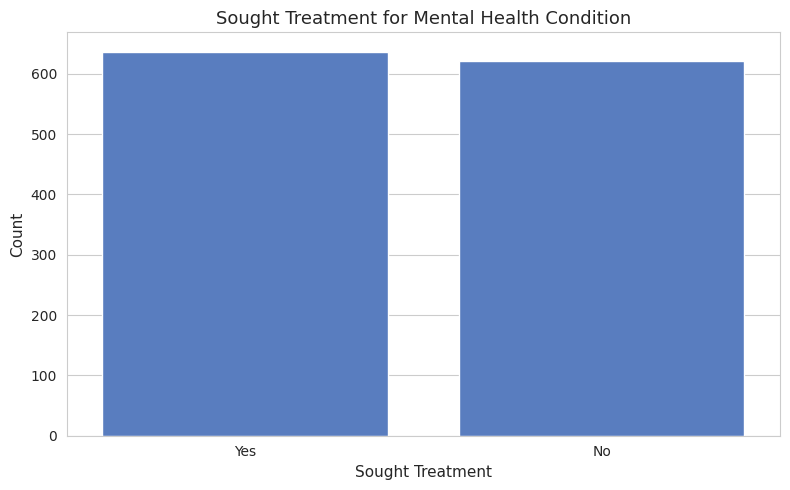

In [16]:
plt.figure()
sns.countplot(data=df, x='treatment')
plt.title('Sought Treatment for Mental Health Condition')
plt.xlabel('Sought Treatment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

treatment is our key target variable, so a simple count plot shows the overall base rate before breaking it down further.

##### 2. What is/are the insight(s) found from the chart?

The split between Yes and No is close to even (roughly 50/50), meaning treatment-seeking is common but far from universal among tech employees who report having a condition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive - it shows tech employees are fairly willing to seek treatment, but the near-even split also means there's real room to increase that number through better support systems.

#### Chart - 5 - Company Size Distribution

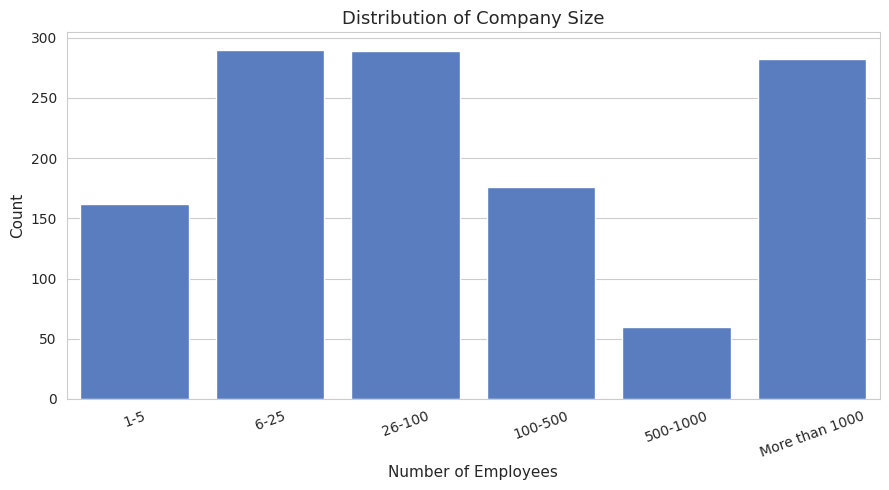

In [17]:
plt.figure(figsize=(9,5))
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
sns.countplot(data=df, x='no_employees', order=order)
plt.title('Distribution of Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A count plot with a manually specified logical order shows the distribution across an ordinal categorical variable clearly.

##### 2. What is/are the insight(s) found from the chart?

Respondents are fairly spread across company sizes, with a noticeable concentration at '26-100' and 'More than 1000' employees - both small startups and large enterprises are well represented.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful for business impact - it means findings can reasonably be generalized across company sizes rather than being skewed toward only startups or only large corporations.

#### Chart - 6 - Family History Distribution

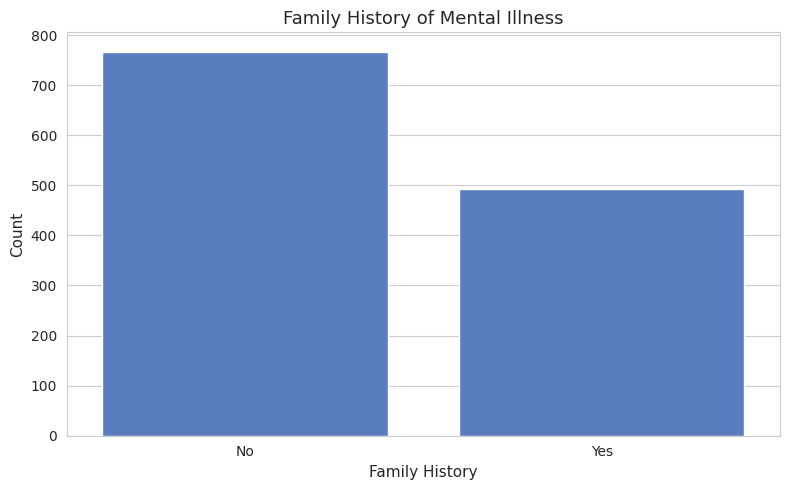

In [18]:
plt.figure()
sns.countplot(data=df, x='family_history')
plt.title('Family History of Mental Illness')
plt.xlabel('Family History')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Simple count plot to see the base rate of this key predictor variable.

##### 2. What is/are the insight(s) found from the chart?

About 39% of respondents report a family history of mental illness, a substantial minority that likely correlates with treatment-seeking behavior (explored in later bivariate charts).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive context - a large base rate of family history means it's a genuinely useful segment for targeted mental health outreach programs.

#### Chart - 7 - Remote Work Distribution

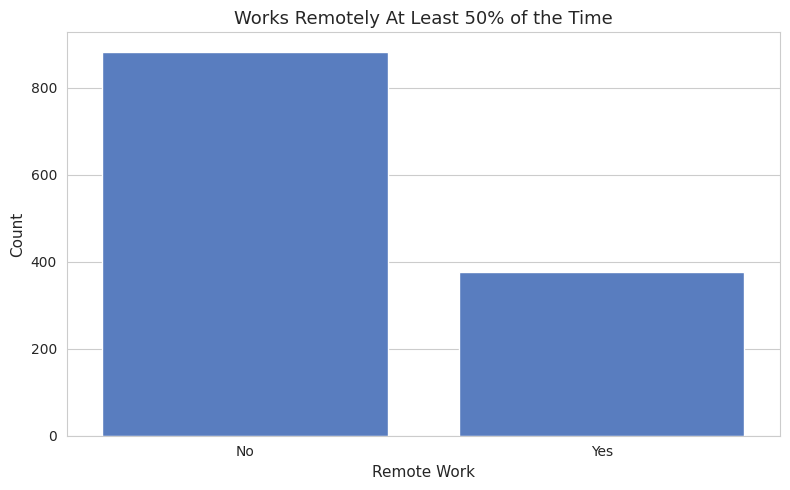

In [19]:
plt.figure()
sns.countplot(data=df, x='remote_work')
plt.title('Works Remotely At Least 50% of the Time')
plt.xlabel('Remote Work')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Count plot to establish the base rate of remote work in this 2014 survey.

##### 2. What is/are the insight(s) found from the chart?

The majority of respondents do not work remotely at least half the time - unsurprising for a 2014 dataset, well before remote work became mainstream.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral/contextual - this tells us remote-work-related findings in this dataset reflect a pre-pandemic-era minority group, so conclusions about remote work shouldn't be over-generalized to today's more remote-friendly tech industry.

#### Chart - 8 - Benefits Distribution

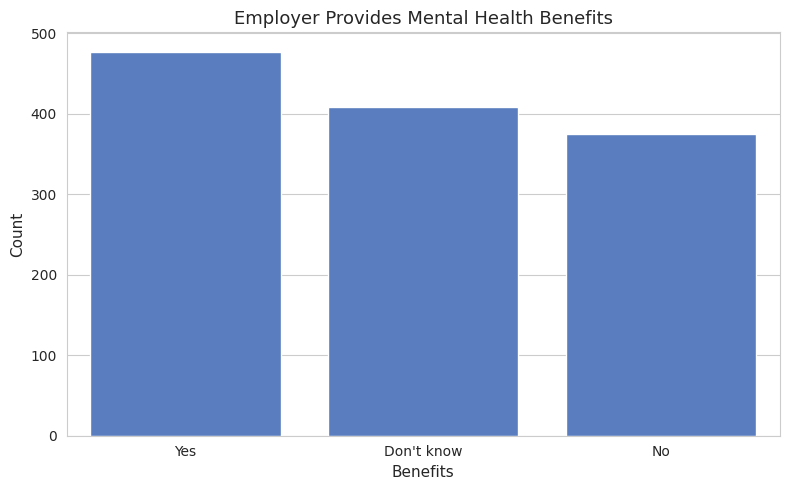

In [20]:
plt.figure()
sns.countplot(data=df, x='benefits', order=df['benefits'].value_counts().index)
plt.title('Employer Provides Mental Health Benefits')
plt.xlabel('Benefits')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Count plot to show how common employer-provided mental health benefits are.

##### 2. What is/are the insight(s) found from the chart?

A significant share of respondents say 'No' or 'Don't know' whether their employer provides mental health benefits, roughly matching those who say 'Yes' - awareness/availability is inconsistent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a negative-growth signal - if a large chunk of employees don't know or don't have mental health benefits, that's a clear gap employers can act on, since benefits are shown later to correlate with treatment-seeking.

#### Chart - 9 - Work Interfere Distribution

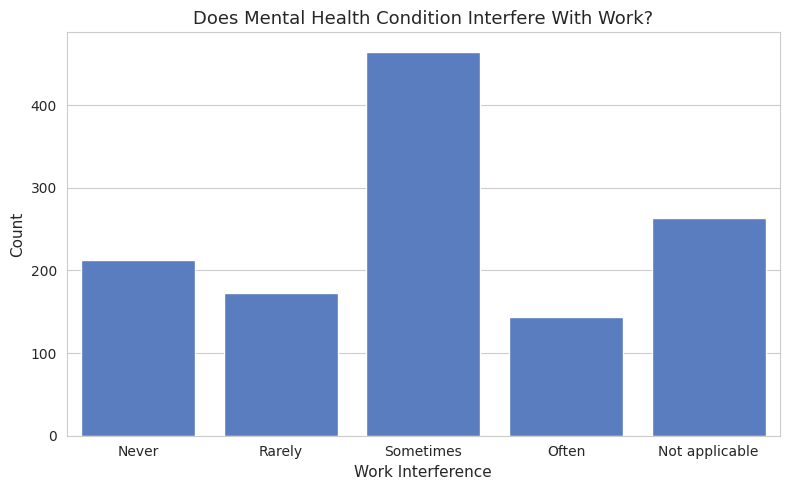

In [21]:
plt.figure()
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
sns.countplot(data=df, x='work_interfere', order=order)
plt.title('Does Mental Health Condition Interfere With Work?')
plt.xlabel('Work Interference')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Ordered count plot fits this naturally ordinal variable (Never < Rarely < Sometimes < Often).

##### 2. What is/are the insight(s) found from the chart?

Among those who answered (excluding 'Not applicable'), 'Sometimes' is the most common response, showing that when mental health conditions exist, they frequently have at least some impact on work performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative growth signal if untreated - frequent work interference suggests productivity impact, which strengthens the business case for investing in mental health support.

#### Chart - 10 - Anonymity Protection Distribution

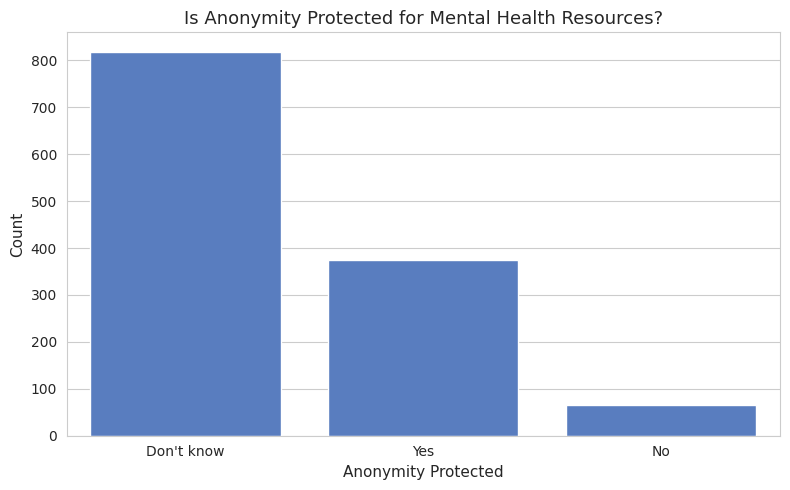

In [22]:
plt.figure()
sns.countplot(data=df, x='anonymity', order=df['anonymity'].value_counts().index)
plt.title("Is Anonymity Protected for Mental Health Resources?")
plt.xlabel('Anonymity Protected')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Count plot to see how confident employees are about anonymity protections.

##### 2. What is/are the insight(s) found from the chart?

A large majority answer 'Don't know' rather than a confident 'Yes' or 'No' - employees are largely uncertain whether their anonymity is protected.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative signal - widespread uncertainty about anonymity likely discourages employees from using mental health resources even if those resources exist, pointing to a communication gap employers should fix.

#### Chart - 11 - Treatment vs Family History

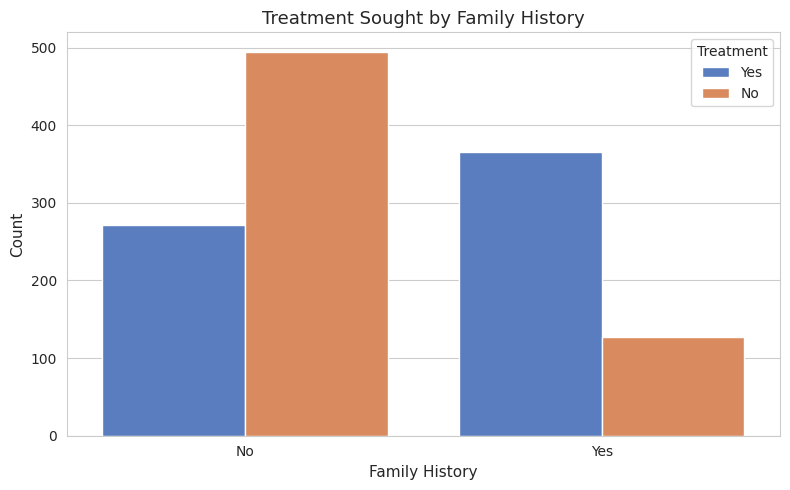

In [23]:
plt.figure()
sns.countplot(data=df, x='family_history', hue='treatment')
plt.title('Treatment Sought by Family History')
plt.xlabel('Family History')
plt.ylabel('Count')
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A grouped count plot (categorical-categorical) clearly compares treatment-seeking rates between the two family-history groups.

##### 2. What is/are the insight(s) found from the chart?

Respondents with a family history of mental illness are considerably more likely to have sought treatment than those without one - family history appears to be one of the strongest predictors in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive - this is highly actionable: employers/HR could proactively offer mental health resources to employees, especially framing outreach around family-history risk factors, to encourage earlier treatment-seeking.

#### Chart - 12 - Treatment vs Work Interference

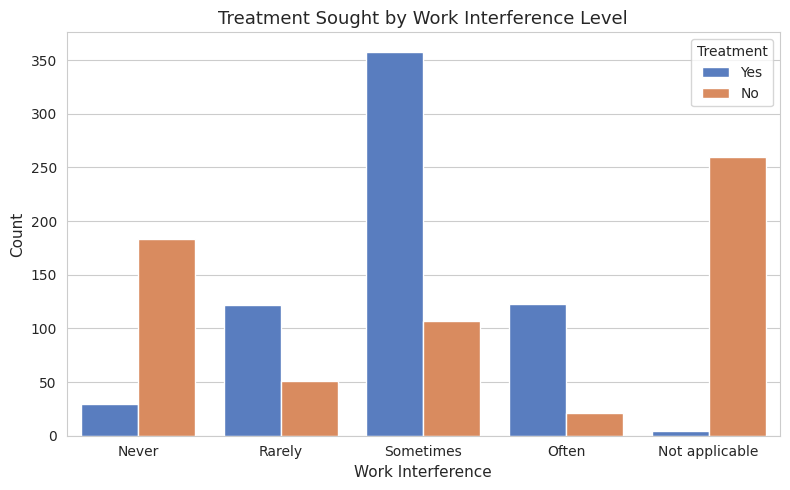

In [24]:
plt.figure()
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
sns.countplot(data=df, x='work_interfere', hue='treatment', order=order)
plt.title('Treatment Sought by Work Interference Level')
plt.xlabel('Work Interference')
plt.ylabel('Count')
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Grouped count plot shows how treatment-seeking varies across levels of an ordinal categorical variable.

##### 2. What is/are the insight(s) found from the chart?

As work interference increases from 'Never' to 'Often', the proportion who sought treatment rises sharply - people whose condition frequently affects their work are much more likely to have gotten treatment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive from a treatment-effectiveness standpoint, but also flags a negative-growth risk: the 'Not applicable'/'Never' group who haven't sought treatment might include undiagnosed cases that could benefit from earlier screening.

#### Chart - 13 - Treatment vs Benefits

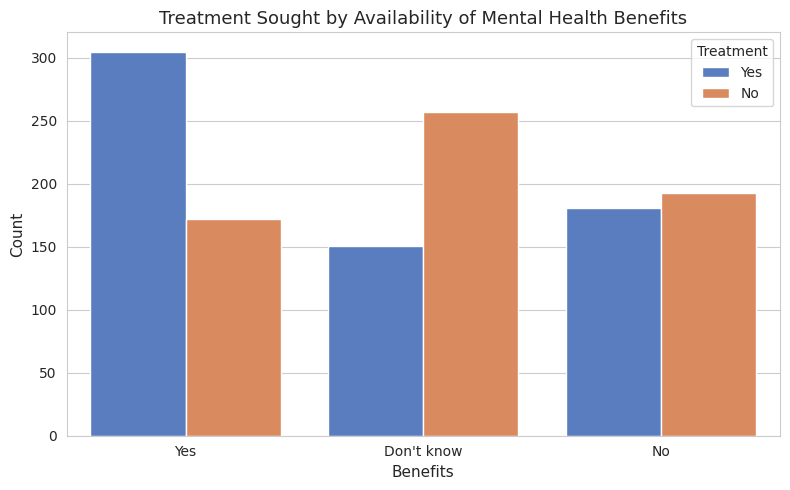

In [25]:
plt.figure()
sns.countplot(data=df, x='benefits', hue='treatment', order=df['benefits'].value_counts().index)
plt.title('Treatment Sought by Availability of Mental Health Benefits')
plt.xlabel('Benefits')
plt.ylabel('Count')
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Grouped count plot compares treatment-seeking across the three benefits-availability categories.

##### 2. What is/are the insight(s) found from the chart?

Employees whose employer provides benefits ('Yes') show a notably higher rate of seeking treatment compared to those who say 'No' or 'Don't know' - suggesting benefits availability (and awareness of it) genuinely encourages treatment-seeking.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strong positive business case - this directly supports investing in and clearly communicating mental health benefits, since it's associated with more employees actually getting help.

#### Chart - 14 - Treatment vs Gender

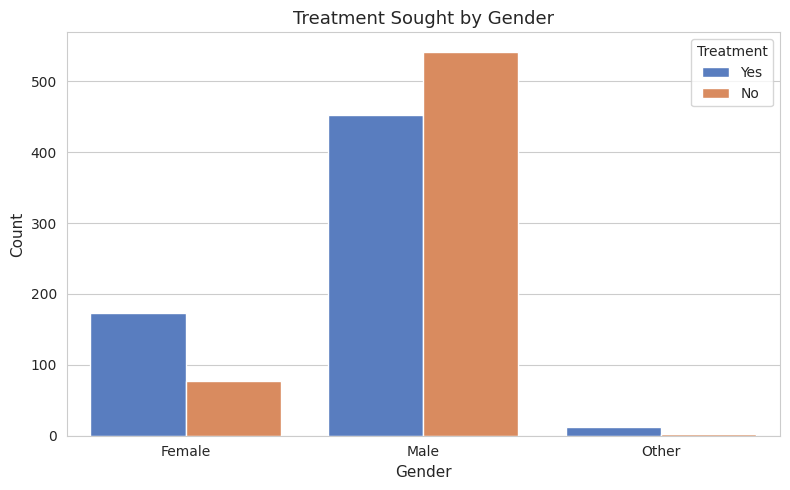

In [26]:
plt.figure()
sns.countplot(data=df, x='Gender', hue='treatment')
plt.title('Treatment Sought by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Grouped count plot compares treatment rates across the cleaned Gender categories.

##### 2. What is/are the insight(s) found from the chart?

Female and Other-gender respondents show a higher proportion seeking treatment relative to their group size compared to Male respondents, though Male respondents dominate in raw counts due to the sample's gender imbalance (see Chart 2).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful for targeted outreach, but should be interpreted cautiously given the small sample sizes for Female and Other groups - no strong negative-growth conclusion should be drawn from this alone.

#### Chart - 15 - Age vs Treatment

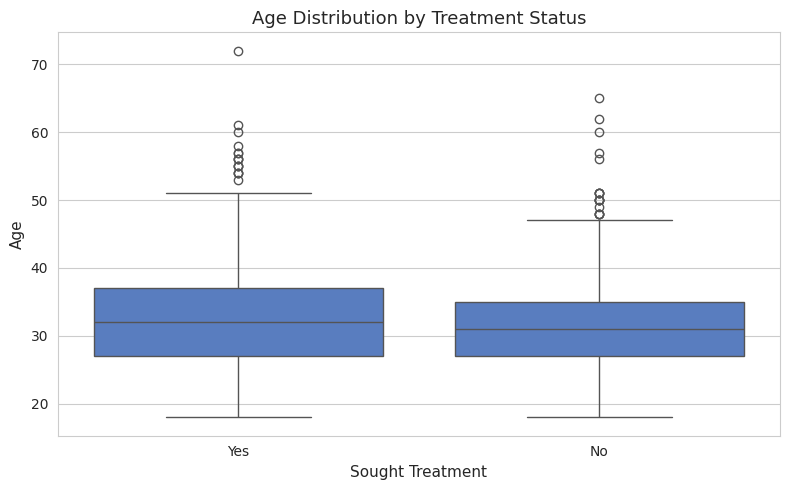

In [27]:
plt.figure()
sns.boxplot(data=df, x='treatment', y='Age')
plt.title('Age Distribution by Treatment Status')
plt.xlabel('Sought Treatment')
plt.ylabel('Age')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A box plot is the standard way to compare the distribution of a numerical variable (Age) across two categorical groups.

##### 2. What is/are the insight(s) found from the chart?

The median age is only slightly higher for those who sought treatment, and the overall spread is similar between both groups - Age by itself is not a strong differentiator of treatment-seeking behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral - this tells the business that age-targeted mental health campaigns alone are unlikely to be effective; other factors like family history and benefits (already shown to matter more) should drive program design instead.

#### Chart - 16 - Treatment vs Remote Work

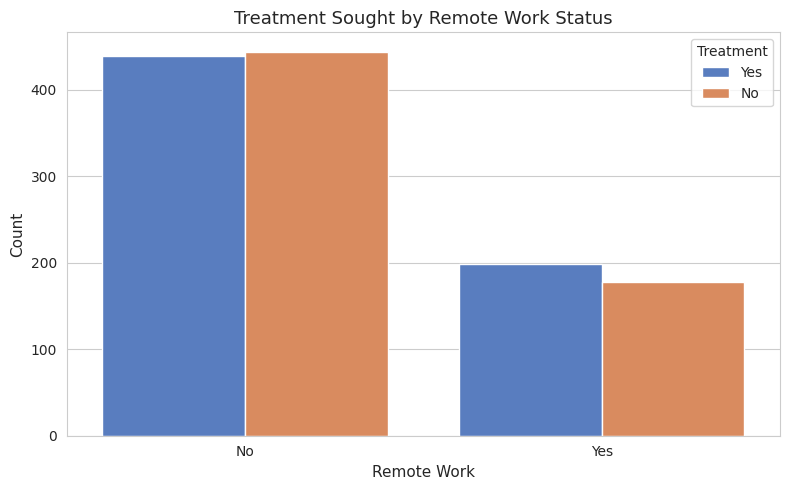

In [28]:
plt.figure()
sns.countplot(data=df, x='remote_work', hue='treatment')
plt.title('Treatment Sought by Remote Work Status')
plt.xlabel('Remote Work')
plt.ylabel('Count')
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Grouped count plot compares treatment rates between remote and non-remote employees.

##### 2. What is/are the insight(s) found from the chart?

The proportion seeking treatment is very similar between remote and non-remote workers - remote work status doesn't show a strong relationship with treatment-seeking in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral - no clear positive or negative business implication here; remote-work policy changes shouldn't be expected to move treatment-seeking rates on their own based on this evidence.

#### Chart - 17 - Treatment Rate by Top 10 Countries

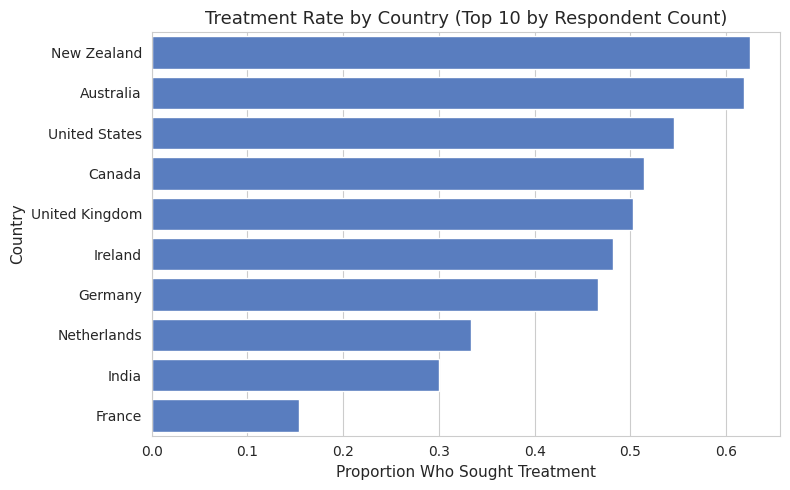

In [29]:
top10 = df['Country'].value_counts().head(10).index
sub = df[df['Country'].isin(top10)]
treat_rate = sub.groupby('Country')['treatment'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)

plt.figure()
sns.barplot(x=treat_rate.values, y=treat_rate.index)
plt.title('Treatment Rate by Country (Top 10 by Respondent Count)')
plt.xlabel('Proportion Who Sought Treatment')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart of a computed rate (proportion seeking treatment) per category is a clean way to compare treatment-seeking across countries with reasonable sample sizes.

##### 2. What is/are the insight(s) found from the chart?

Treatment rates vary noticeably by country - some countries show notably higher treatment-seeking proportions than others, which may reflect differing healthcare access, cultural attitudes, or stigma levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive/negative depends on the country: countries with low treatment rates despite meaningful sample sizes represent a negative-growth risk (unmet mental health need) that a global employer should address with region-specific support.

#### Chart - 18 - Treatment vs Company Size

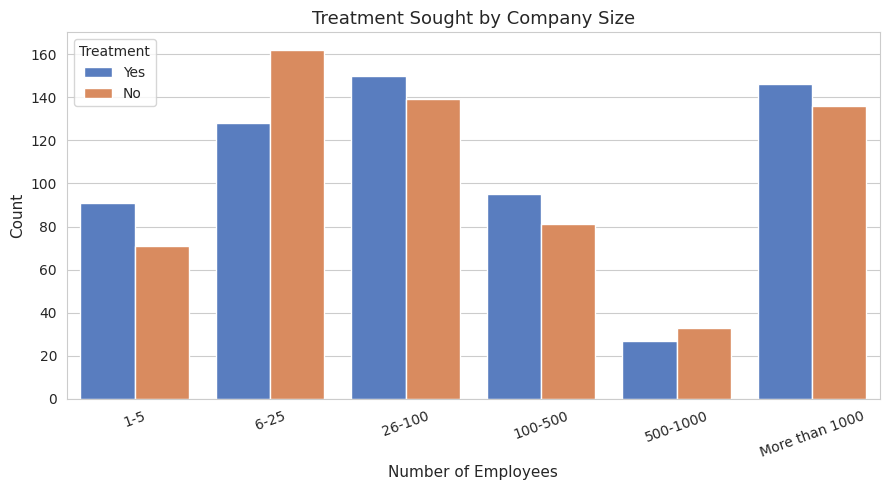

In [30]:
plt.figure(figsize=(9,5))
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
sns.countplot(data=df, x='no_employees', hue='treatment', order=order)
plt.title('Treatment Sought by Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Grouped count plot across the ordinal company-size categories shows how treatment-seeking shifts with organization scale.

##### 2. What is/are the insight(s) found from the chart?

Treatment-seeking proportions look fairly similar across company sizes, though very large companies ('More than 1000') show a slightly higher share seeking treatment, possibly due to more comprehensive benefits.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mildly positive for large employers, but also suggests smaller companies (1-5, 6-25) may need to catch up on providing accessible mental health support relative to larger peers.

#### Chart - 19 - Willingness to Discuss with Coworkers vs Supervisor

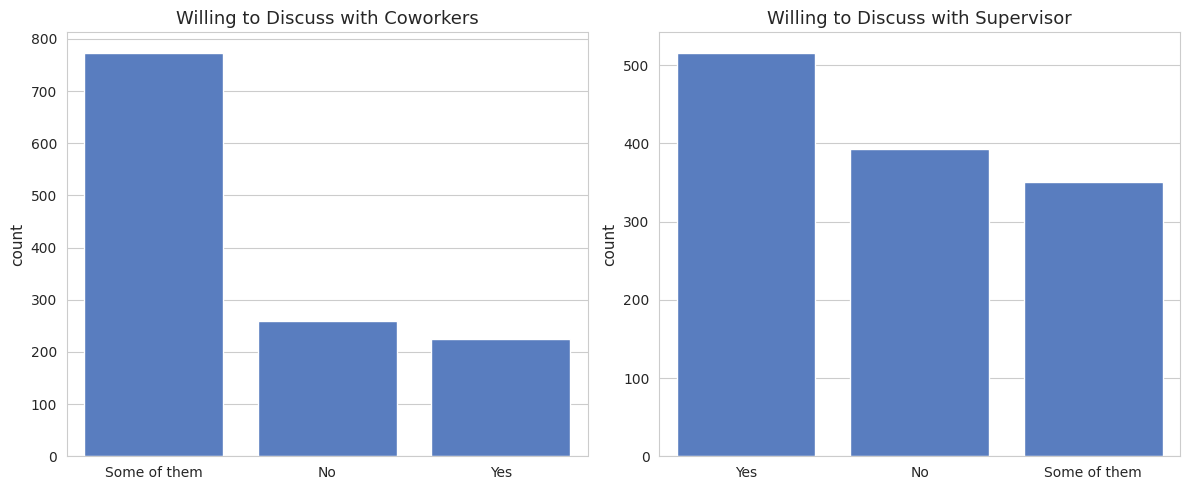

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='coworkers', ax=axes[0], order=df['coworkers'].value_counts().index)
axes[0].set_title('Willing to Discuss with Coworkers')
axes[0].set_xlabel('')
sns.countplot(data=df, x='supervisor', ax=axes[1], order=df['supervisor'].value_counts().index)
axes[1].set_title('Willing to Discuss with Supervisor')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A side-by-side pair of count plots (categorical-categorical comparison across two related columns) makes it easy to directly compare comfort levels with two different audiences at work.

##### 2. What is/are the insight(s) found from the chart?

Employees are somewhat more willing to discuss mental health with 'Some of them' coworkers than with supervisors directly, and 'No' responses are notably higher for supervisors - trust in a direct manager appears lower than trust in peers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative-growth signal if unaddressed - low comfort discussing mental health with supervisors could mean issues go unreported to the people best positioned to grant accommodations, pointing to a need for manager training on this topic.

#### Chart - 20 - Benefits, Wellness Program & Seek Help (Multivariate)

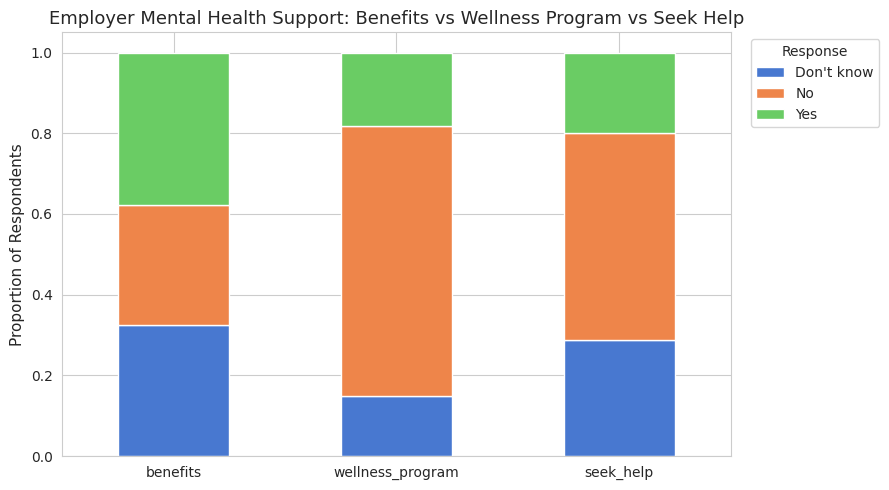

In [32]:
support_cols = ['benefits', 'wellness_program', 'seek_help']
support_df = df[support_cols].apply(lambda col: col.value_counts(normalize=True)).T

plt.figure(figsize=(9, 5))
support_df.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Employer Mental Health Support: Benefits vs Wellness Program vs Seek Help')
plt.ylabel('Proportion of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Response', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A stacked bar chart across three related support-related columns at once gives a multivariate view of how consistently (or inconsistently) employers offer different layers of mental health support.

##### 2. What is/are the insight(s) found from the chart?

'Don't know' responses are common across all three support dimensions, and 'wellness_program' has the lowest 'Yes' share of the three - employers are more likely to offer basic benefits than to actively discuss mental health through wellness programs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative-growth signal - having benefits on paper but not reinforcing them through wellness programs or clear 'seek help' resources means employees may not actually know support exists, reducing the real-world impact of those benefits.

#### Chart - 21 - Treatment by Gender and Family History (Multivariate)

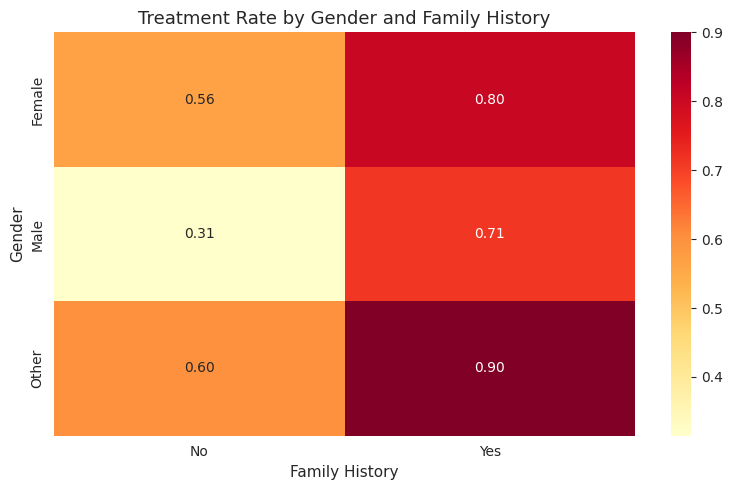

In [33]:
pivot = df.pivot_table(index='Gender', columns='family_history', values='treatment',
                        aggfunc=lambda x: (x == 'Yes').mean())

plt.figure()
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Treatment Rate by Gender and Family History')
plt.xlabel('Family History')
plt.ylabel('Gender')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A heatmap of an aggregated rate across two categorical dimensions at once is an efficient way to show a true multivariate (3-way) relationship: Gender x Family History x Treatment rate.

##### 2. What is/are the insight(s) found from the chart?

Across every gender group, having a family history of mental illness is associated with a markedly higher treatment rate, and this effect holds consistently for Male, Female, and Other - family history is a robust predictor regardless of gender.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive - this reinforces that family-history-based outreach is broadly applicable across all gender groups, making it a reliable, low-risk lever for HR programs to prioritize.

#### Chart - 22 - Correlation Heatmap

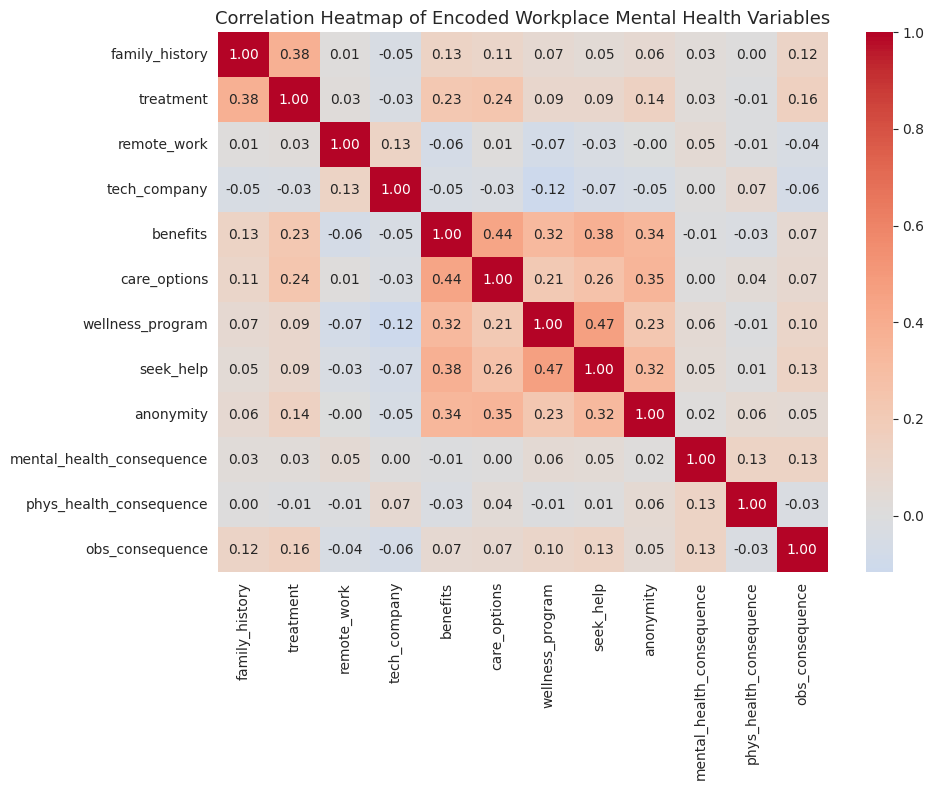

In [34]:
# Correlation Heatmap visualization code
encode_cols = ['family_history', 'treatment', 'remote_work', 'tech_company',
               'benefits', 'care_options', 'wellness_program', 'seek_help',
               'anonymity', 'mental_health_consequence', 'phys_health_consequence',
               'obs_consequence']

df_encoded = df[encode_cols].apply(lambda col: col.astype('category').cat.codes)

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Encoded Workplace Mental Health Variables')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to view pairwise relationships across many encoded categorical variables simultaneously, helping spot which workplace factors move together.

##### 2. What is/are the insight(s) found from the chart?

`treatment` shows its strongest positive correlations with `family_history` and `care_options`, while `mental_health_consequence` and `obs_consequence` correlate positively with each other - suggesting fear of consequences and actually observing consequences reinforce one another.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis, tech employers should prioritize four concrete actions. First, clearly communicate and reinforce existing mental health benefits and care options - many employees answered 'Don't know' rather than 'Yes' or 'No' for benefits, anonymity, and wellness programs, meaning awareness (not just availability) is the bottleneck. Second, invest specifically in manager/supervisor training, since employees are notably less comfortable discussing mental health with supervisors than with coworkers - this gap likely prevents timely accommodations. Third, use family history as a signal for proactive, opt-in outreach (e.g. offering resources during onboarding or open enrollment), since it was the strongest and most consistent predictor of treatment-seeking across all genders and company sizes. Fourth, smaller companies (1-5 to 6-25 employees) should be supported with affordable mental health benefit options, since they currently appear to lag larger organizations in this analysis.

# **Conclusion**

This EDA of the 2014 OSMI Mental Health in Tech Survey shows that treatment-seeking behavior is most strongly associated with family history of mental illness and the availability (and awareness) of employer-provided benefits, while age, remote-work status, and company size show weaker relationships. Employees are considerably more comfortable discussing mental health with coworkers than with supervisors, and widespread uncertainty ('Don't know') about anonymity protections and wellness programs suggests a communication gap rather than a lack of policy. Geographic analysis is dominated by US respondents, so country-level conclusions should be treated as directional rather than definitive. Overall, the findings point toward manager training, clearer communication of existing benefits, and family-history-based proactive outreach as the highest-leverage next steps for improving mental health support in tech workplaces.